# "master instruction” (onderdeel van prompt — EDA-breed, dus voor elke EDA notebook (phase2))

Je werkt als senior research assistant voor een masterthesis in data analysis. Voor meer informatie over de thesis / onderzoeksvoorstel / opzet: bekijk bron "Geannoteerd_onderzoeksvoorstel.md" en voor extra gelinkte literatuur bron; "External factors and SHAP in Urban Parking copy.pdf" (beide bestanden zijn te vinden in de map 'literatuur_en_info' (binnen dit project)) 

voor structuur en gewenste flow check projectalomvattede: "README.md"

Context:
- Projectfase: Phase 2 — Exploratieve Data Analyse (EDA)
- Domein: parkeerbezetting van off-street parkings
- Doel: een academisch rigoureuze, reproduceerbare, hypothese-gedreven EDA uitvoeren die als uitstekende basis dient voor Phase 3 (Feature Engineering)
- Dataset(s): parquet-output uit Phase 1, met minstens MAD_shortterm en MAD_longterm
- Onderzoekslogica: tier-stratified analyse, met bijzondere aandacht voor temporal, spatial en external drivers
- Werkomgeving: VS Code + Jupyter notebooks
- Jij mag iteratief werken: je moet je eigen code-output lezen, interpreteren, evalueren, samenvatten, en op basis daarvan de volgende analytische stap bepalen

Belangrijke werkinstructies:
1. Werk notebook-native: schrijf steeds code in duidelijke, logisch gegroepeerde cellen.
2. Na elke analytische sectie moet je:
   - de output lezen,
   - een academische interpretatie geven,
   - expliciet vermelden welke hypothese(n) voorlopig ondersteund, verworpen of genuanceerd worden,
   - beslissen wat de volgende logische stap is.
3. Werk reproductief:
   - gebruik vaste paden/variabelen bovenaan,
   - schrijf nette helperfuncties indien nuttig,
   - vermijd rommelige eenmalige code.
4. Werk academisch:
   - beschrijf patronen voorzichtig,
   - maak onderscheid tussen descriptieve associatie en causale claim,
   - benoem beperkingen, datakwaliteit en mogelijke bias.
5. Indien je literatuur gebruikt:
   - voeg APA7-verwijzingen toe in markdown,
   - gebruik alleen controleerbare bronnen,
   - koppel hypotheses enkel aan literatuur als dat inhoudelijk verdedigbaar is.
6. Maak analyses direct nuttig voor Phase 3:
   - signaleer mogelijke feature candidates,
   - signaleer risico op leakage,
   - noteer niet-lineariteiten, interacties, segmentaties en transformaties.
7. Focus in EDA niet op “zoveel mogelijk grafieken”, maar op analytische waarde.
8. Rapporteer steeds ook wat NIET overtuigend blijkt.
9. Gebruik waar relevant robuuste statistiek, effectgroottes en multiple-testing-bewustzijn.
10. Sluit elk notebook af met een sectie:
   - "Key findings"
   - "Implications for feature engineering"
   - "Open questions for next notebook"

Wanneer je literatuur gebruikt om een hypothese te motiveren:
- gebruik alleen bronnen die inhoudelijk echt passen bij parkeerbezetting, mobiliteit, weersinvloeden, events, forecasting of XAI;
- label speculatieve hypothesen expliciet als speculatief maar toetsbaar;
- geef APA7-verwijzingen in markdown;
- vermijd het doen alsof literatuur causale evidentie levert wanneer het eigenlijk om associatieve studies gaat;
- als de data de literatuur niet ondersteunen, rapporteer dat eerlijk.

Technische stijlregels:
- Python: pandas, numpy, scipy, statsmodels, matplotlib, seaborn/plotly enkel indien functioneel, sklearn indien nodig
- Plotstijl: professioneel, leesbaar, consistente labels en units
- Timestamps correct behandelen
- (enkel indien expliciet handig, nodig, belangrijk) Segmentaties minstens per:
  - shortterm vs longterm
  - parking/tier/location category
  - event vs non-event
  - weekday/weekend
  - holiday/vacation/regular day waar relevant

Schrijf elke interpretatieve markdown-sectie alsof ze later kan worden herwerkt tot tekst voor de masterthesis.

Stijlregels:
- helder, academisch, voorzichtig
- geen losse bullet dump als lopende tekst beter is
- benoem richting, grootteorde, onzekerheid en beperking
- maak expliciet waarom het resultaat relevant is voor de volgende fase

Jouw taak is niet enkel code schrijven, maar ook analytisch denken als thesis-assistent.

# Notebook specifieke prompt

Maak notebook `eda_04_external_factors.ipynb`.

Doel:
De relatie tussen externe factoren en parkeerbezetting analyseren, descriptief en hypothese-gedreven.

Focushypothesen:
- H-E1: neerslag heeft mogelijk niet-lineair effect
- H-E2: temperatuur werkt seizoensgebonden / interactief
- H-E3: bezetting stijgt voor events en daalt gefaseerd na events
- H-E4: feestdagen werken verschillend per tier
- H-E5: temperatuur en maand kunnen multicollineariteit / gedeelde seizoensstructuur vertonen
- H-E6: sterke wind kan samenhangen met hogere bezetting
- H-E7: zonneschijn kan in zomer negatief samenhangen met bezetting
- H-E8: schoolvakanties beïnvloeden centrum en rand verschillend
- H-E9: eventeffect schaalt mee met eventomvang
- Vul nog hypotheses aan: betekenisvolle, kritische, nodige, belangrijke, sterke, academisch onderbouwde, (kan onder andere gericht zijn op phase3 feature engineering) aanvullende , versterkende hypotheses

Voer dit uit:
0. Analyseer de eerdere  eda notebooks, zodat je geen dubbelwerk doet, geen nutteloos werk doet, kritisch gericht kan werken, interne consistentie kunt nastreven, ...
1. Beschrijf eerst coverage en kwaliteit van externe variabelen:
   - weather missings
   - QC-flags
   - imputatieflags
   - eventdata-confidence
2. Analyseer weather vs occupancy:
   - temp_c
   - precip_mm
   - wind_speed_ms / gusts
   - humidity_pct
   - sun_duration_min / radiation proxies
3. Doe dit niet alleen lineair:
   - bins/quantiles
   - smoothers
   - conditional plots per seizoen of per month
4. Analyseer calendar effects:
   - holiday vs non-holiday
   - school vacation vs non-vacation
   - national vs other holiday
   - calendar_day_class
5. Analyseer event effects:
   - event_day vs non-event_day
   - per eventtype
   - per event_scale_max
   - per n_concurrent_events
   - indien timing toelaat: voor/na eventvensters rond football_kickoff_hour
6. Onderzoek interacties:
   - event × tier
   - holiday × tier
   - weather × season
   - weather × shortterm/longterm
   - eventueel extra's indien je hier mogelijkehden tot ziet (uit de data halen + ten allentijde goed argumenten)
7. Rapporteer voor elke externe driver:
   - effectrichting
   - vorm (lineair / niet-lineair / drempelmatig / onduidelijk)
   - stabiliteit over segmenten
   - bruikbaarheid voor feature engineering
8. Sluit af met:
   - overzicht per hypothese
   - welke externe variabelen lijken echt informatief?
   - welke vereisen transformatie, bins, interacties of voorzichtigheid?

Belangrijk:
- Geen causale taal.
- Corrigeer jezelf wanneer seizoensconfounding waarschijnlijk is.
- Als een effect waarschijnlijk spurious of instabiel is, benoem dat.

## 0. Setup en consistentie met eerdere EDA-notebooks

Deze notebook volgt de beslissingen uit `eda_00` t.e.m. `eda_03`:
- analyse op `occupancy_rate` als hoofdtarget;
- primair op kwaliteitsgefilterde data (`system_blackout`, `low_data_coverage`, `partial_year`, `flag_occ_inconsistent` uitgesloten);
- systematische splitsing shortterm versus longterm;
- expliciete voorzichtigheid voor confounding (tijd/season/eventmix) en geen causale taal.

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from scipy.stats import spearmanr
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid", context="notebook", palette="colorblind")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "data_processed").exists() and (candidate / "notebooks").exists():
            return candidate
    raise FileNotFoundError("Project root not found from current working directory")


def as_flag(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce").fillna(0).gt(0)


def build_quality_mask(df: pd.DataFrame) -> pd.Series:
    mask = pd.Series(True, index=df.index)
    for col in ["system_blackout", "low_data_coverage", "partial_year", "flag_occ_inconsistent"]:
        if col in df.columns:
            mask &= ~as_flag(df[col])
    mask &= pd.to_numeric(df["occupancy_rate"], errors="coerce").between(0, 1, inclusive="both")
    return mask


def binary_effect(df: pd.DataFrame, flag_col: str, target_col: str = "occupancy_rate", min_n: int = 30) -> dict:
    flag = as_flag(df[flag_col])
    n1 = int(flag.sum())
    n0 = int((~flag).sum())

    out = {
        "flag_col": flag_col,
        "n_true": n1,
        "n_false": n0,
        "mean_true": np.nan,
        "mean_false": np.nan,
        "delta_true_minus_false": np.nan,
    }

    if n1 >= min_n and n0 >= min_n:
        mean_true = float(df.loc[flag, target_col].mean())
        mean_false = float(df.loc[~flag, target_col].mean())
        out.update(
            {
                "mean_true": mean_true,
                "mean_false": mean_false,
                "delta_true_minus_false": mean_true - mean_false,
            }
        )
    return out


def weighted_month_adjusted_delta(df: pd.DataFrame, flag_col: str, target_col: str = "occupancy_rate", min_n: int = 20) -> float:
    rows = []
    for month, grp in df.groupby("month"):
        f = as_flag(grp[flag_col])
        if int(f.sum()) < min_n or int((~f).sum()) < min_n:
            continue
        delta = float(grp.loc[f, target_col].mean() - grp.loc[~f, target_col].mean())
        rows.append({"month": month, "delta": delta, "weight": len(grp)})

    if not rows:
        return np.nan

    t = pd.DataFrame(rows)
    return float((t["delta"] * t["weight"]).sum() / t["weight"].sum())


def spearman_safe(df: pd.DataFrame, x: str, y: str = "occupancy_rate", min_n: int = 100):
    d = df[[x, y]].dropna()
    if len(d) < min_n:
        return np.nan, np.nan, len(d)
    rho, p = spearmanr(d[x], d[y])
    return float(rho), float(p), int(len(d))


def lowess_frame(df: pd.DataFrame, x_col: str, y_col: str = "occupancy_rate", frac: float = 0.2, max_points: int = 40000) -> pd.DataFrame:
    d = df[[x_col, y_col]].dropna().copy()
    if len(d) > max_points:
        d = d.sample(max_points, random_state=42)
    d = d.sort_values(x_col)

    if len(d) < 200:
        return pd.DataFrame(columns=[x_col, "y_smooth"])

    sm = lowess(d[y_col], d[x_col], frac=frac, return_sorted=True)
    return pd.DataFrame({x_col: sm[:, 0], "y_smooth": sm[:, 1]})


PROJECT_ROOT = find_project_root()

# === AUTO-EXPORT ARTIFACTS (figures + displayed tables) ===
NOTEBOOK_SLUG = "eda_04_external_factors"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "phase2" / NOTEBOOK_SLUG
FIG_DIR = ARTIFACTS_DIR / "figures"
TABLE_DIR = ARTIFACTS_DIR / "tables"
LOG_DIR = ARTIFACTS_DIR / "logs"

for _d in [ARTIFACTS_DIR, FIG_DIR, TABLE_DIR, LOG_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def _safe_artifact_name(name: str) -> str:
    allowed = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789_-")
    s = "".join(ch if ch in allowed else "_" for ch in str(name))
    while "__" in s:
        s = s.replace("__", "_")
    s = s.strip("_")
    return s or "artifact"


def save_dataframe_artifact(df: pd.DataFrame, name: str, index: bool = True) -> dict[str, str | None]:
    base = _safe_artifact_name(name)
    csv_path = TABLE_DIR / f"{base}.csv"
    parquet_path = TABLE_DIR / f"{base}.parquet"

    df.to_csv(csv_path, index=index)
    parquet_ok = True
    try:
        df.to_parquet(parquet_path, index=index)
    except Exception:
        parquet_ok = False

    return {
        "csv": str(csv_path),
        "parquet": str(parquet_path) if parquet_ok else None,
    }


if not globals().get("_DISPLAY_AUTO_EXPORT_PATCHED", False):
    _DISPLAY_AUTO_EXPORT_PATCHED = True
    _ORIG_DISPLAY = display
    _DISPLAY_COUNTER = {"n": 0}

    def display(*objs, **kwargs):
        for obj in objs:
            if isinstance(obj, pd.DataFrame):
                _DISPLAY_COUNTER["n"] += 1
                save_dataframe_artifact(obj, f"display_{_DISPLAY_COUNTER['n']:03d}", index=True)
        return _ORIG_DISPLAY(*objs, **kwargs)


try:
    import matplotlib.pyplot as plt  # noqa: F401

    if not getattr(plt, "_AUTO_EXPORT_PATCHED", False):
        _ORIG_PLT_SHOW = plt.show
        _FIG_COUNTER = {"n": 0}

        def _show_and_save(*args, **kwargs):
            fig_nums = list(plt.get_fignums())
            for fig_num in fig_nums:
                fig = plt.figure(fig_num)
                _FIG_COUNTER["n"] += 1
                fig_path = FIG_DIR / f"fig_{_FIG_COUNTER['n']:03d}.png"
                fig.savefig(fig_path, dpi=150, bbox_inches="tight")
            return _ORIG_PLT_SHOW(*args, **kwargs)

        plt.show = _show_and_save
        plt._AUTO_EXPORT_PATCHED = True
    FIG_EXPORT_ENABLED = True
except Exception:
    FIG_EXPORT_ENABLED = False

print(f"Artifacts directory: {ARTIFACTS_DIR}")
print(f"- Figures: {FIG_DIR}")
print(f"- Tables: {TABLE_DIR}")

DATA_DIR = PROJECT_ROOT / "data_processed"

DATA_PATHS = {
    "shortterm": DATA_DIR / "MAD_shortterm.parquet",
    "longterm": DATA_DIR / "MAD_longterm.parquet",
}

SEASON_MAP = {
    12: "winter", 1: "winter", 2: "winter",
    3: "lente", 4: "lente", 5: "lente",
    6: "zomer", 7: "zomer", 8: "zomer",
    9: "herfst", 10: "herfst", 11: "herfst",
}

raw_dfs = {}
filtered_dfs = {}

for dataset_label, path in DATA_PATHS.items():
    if not path.exists():
        raise FileNotFoundError(f"Dataset ontbreekt: {dataset_label} -> {path}")

    df = pd.read_parquet(path).copy()
    df["dataset_label"] = dataset_label
    df["rounded_hour"] = pd.to_datetime(df["rounded_hour"], errors="coerce")
    df["date_only"] = pd.to_datetime(df["date_only"], errors="coerce")
    df["season"] = df["month"].map(SEASON_MAP)
    df["tier_temporal"] = np.where(df["parking_location_category"].astype(str).eq("centrum"), "centrum", "vesten_of_rand")
    df["is_weekend"] = df["weekday_int"].isin([5, 6])

    raw_dfs[dataset_label] = df
    filtered_dfs[dataset_label] = df.loc[build_quality_mask(df)].copy()

analysis_df = pd.concat(filtered_dfs.values(), ignore_index=True)

overview_rows = []
for label in ["shortterm", "longterm"]:
    d0 = raw_dfs[label]
    d1 = filtered_dfs[label]
    overview_rows.append(
        {
            "dataset_label": label,
            "n_raw": int(len(d0)),
            "n_quality_filtered": int(len(d1)),
            "pct_retained": float(len(d1) / len(d0) * 100),
            "n_parkings": int(d1["parking_id"].nunique()),
            "date_min": d1["rounded_hour"].min(),
            "date_max": d1["rounded_hour"].max(),
            "years": ", ".join(map(str, sorted(d1["year"].dropna().unique().tolist()))),
        }
    )

overview_df = pd.DataFrame(overview_rows).set_index("dataset_label")
display(overview_df)

Artifacts directory: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_04_external_factors
- Figures: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_04_external_factors/figures
- Tables: /Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/artifacts/phase2/eda_04_external_factors/tables


,n_raw,n_quality_filtered,pct_retained,n_parkings,date_min,date_max,years
dataset_label,,,,,,,
shortterm,284524,250437,88.01964,10,2019-01-01,2025-12-31 23:00:00,"2019, 2020, 2023, 2024, 2025"
longterm,46643,46643,100.00000,7,2024-01-01,2024-12-31 22:00:00,2024


### Hypothese register (external factors)

- **H-E1**: neerslag heeft mogelijk niet-lineair effect.
- **H-E2**: temperatuur werkt seizoensgebonden / interactief.
- **H-E3**: bezetting stijgt voor events en daalt gefaseerd na events.
- **H-E4**: feestdagen werken verschillend per tier.
- **H-E5**: temperatuur en maand kunnen multicollineariteit / gedeelde seizoensstructuur vertonen.
- **H-E6**: sterke wind kan samenhangen met hogere bezetting.
- **H-E7**: zonneschijn kan in zomer negatief samenhangen met bezetting.
- **H-E8**: schoolvakanties beïnvloeden centrum en rand verschillend.
- **H-E9**: eventeffect schaalt mee met eventomvang.
- **H-E10 (aanvullend)**: externe effecten verschillen tussen shortterm en longterm.
- **H-E11 (aanvullend)**: eventeffecten zijn gevoelig voor season/event-confidence confounding.

## 1. Coverage en datakwaliteit van externe variabelen

In [2]:
WEATHER_COLS = [
    "temp_c",
    "precip_mm",
    "wind_speed_ms",
    "wind_gusts_ms",
    "humidity_pct",
    "sun_duration_min",
    "shortwave_wm2",
    "sun_intensity_wm2",
]

QC_COLS = [c for c in analysis_df.columns if c.startswith("qc_")]
IMPUTATION_FLAGS = ["precip_imputed", "humidity_suspect", "sun_duration_inconsistent"]

# Missingness weather
weather_missing_rows = []
for dataset_label, df in filtered_dfs.items():
    miss = (df[WEATHER_COLS].isna().mean() * 100).to_dict()
    for col, pct in miss.items():
        weather_missing_rows.append(
            {
                "dataset_label": dataset_label,
                "variable": col,
                "missing_pct": float(pct),
            }
        )

weather_missing_df = pd.DataFrame(weather_missing_rows)

# QC overview
qc_rows = []
for dataset_label, df in filtered_dfs.items():
    for col in QC_COLS:
        vc = df[col].value_counts(dropna=False)
        qc_rows.append(
            {
                "dataset_label": dataset_label,
                "qc_col": col,
                "dtype": str(df[col].dtype),
                "missing_pct": float(df[col].isna().mean() * 100),
                "true_pct": float(vc.get(True, 0) / len(df) * 100),
                "false_pct": float(vc.get(False, 0) / len(df) * 100),
            }
        )

qc_df = pd.DataFrame(qc_rows)

# Imputatie/suspect flags
imputation_rows = []
for dataset_label, df in filtered_dfs.items():
    for col in IMPUTATION_FLAGS:
        if col in df.columns:
            imputation_rows.append(
                {
                    "dataset_label": dataset_label,
                    "flag_col": col,
                    "flag_pct": float(as_flag(df[col]).mean() * 100),
                }
            )
imputation_df = pd.DataFrame(imputation_rows)

# data_confidence + relatie met event_day
confidence_rows = []
for dataset_label, df in filtered_dfs.items():
    conf_dist = df["data_confidence"].value_counts(normalize=True, dropna=False)
    for conf, pct in conf_dist.items():
        sub = df.loc[df["data_confidence"] == conf]
        event_pct = float(as_flag(sub["is_event_day"]).mean() * 100) if len(sub) > 0 else np.nan
        confidence_rows.append(
            {
                "dataset_label": dataset_label,
                "data_confidence": conf,
                "share_pct": float(pct * 100),
                "event_day_pct_within_confidence": event_pct,
                "n_obs": int(len(sub)),
            }
        )

confidence_df = pd.DataFrame(confidence_rows)

print("Weather missingness (%)")
display(weather_missing_df.pivot(index="variable", columns="dataset_label", values="missing_pct").round(3))

print("QC-overzicht")
display(qc_df.round(4))

print("Imputatie/suspect flags")
display(imputation_df.round(4))

print("Event data confidence")
display(confidence_df.sort_values(["dataset_label", "share_pct"], ascending=[True, False]).round(4))

Weather missingness (%)


dataset_label,longterm,shortterm
variable,,
humidity_pct,0.0,13.177
precip_mm,0.0,13.177
shortwave_wm2,0.0,13.177
sun_duration_min,0.0,13.177
sun_intensity_wm2,0.0,13.177
temp_c,0.0,13.177
wind_gusts_ms,0.0,13.177
wind_speed_ms,0.0,13.177


QC-overzicht


,dataset_label,qc_col,dtype,missing_pct,true_pct,false_pct
0,shortterm,qc_temp,object,13.177,86.4002,0.4229
1,shortterm,qc_precip,object,13.177,86.6214,0.2016
2,shortterm,qc_wind_speed,object,13.177,86.5611,0.2619
3,shortterm,qc_wind_gusts,object,13.177,86.5591,0.2639
4,shortterm,qc_humidity,object,13.177,70.4656,16.3574
5,shortterm,qc_pressure,object,13.177,86.5319,0.2911
6,longterm,qc_temp,bool,0.000,99.7749,0.2251
7,longterm,qc_precip,bool,0.000,99.8864,0.1136
8,longterm,qc_wind_speed,bool,0.000,99.7749,0.2251
9,longterm,qc_wind_gusts,bool,0.000,99.7749,0.2251


Imputatie/suspect flags


,dataset_label,flag_col,flag_pct
0,shortterm,precip_imputed,0.0060
1,shortterm,humidity_suspect,16.3574
2,shortterm,sun_duration_inconsistent,2.5236
3,longterm,precip_imputed,0.0000
4,longterm,humidity_suspect,5.3106
5,longterm,sun_duration_inconsistent,3.7369


Event data confidence


,dataset_label,data_confidence,share_pct,event_day_pct_within_confidence,n_obs
2,longterm,verified,88.5642,22.8715,41309
3,longterm,estimated,11.4358,100.0000,5334
0,shortterm,verified,94.8446,20.5830,237526
1,shortterm,estimated,5.1554,100.0000,12911


**Interpretatie**

De kwaliteit van externe variabelen verschilt sterk per dataset: shortterm bevat substantiële weather-missingness en meer QC-variatie, terwijl longterm vrijwel volledig is voor weerdata. Dit bevestigt dat shortterm-resultaten gevoeliger zijn voor meet-/coverage-artefacten.

`data_confidence` blijkt inhoudelijk belangrijk: `estimated` observaties vallen vrijwel volledig samen met eventdagen. Dat maakt eventeffecten extra confound-gevoelig en moet expliciet vermeld blijven in interpretaties.

**Volgende logische stap**
- Weather-effecten analyseren met zowel lineaire als niet-lineaire en seizoensconditionele invalshoeken.

## 2. Weather versus occupancy (lineair, niet-lineair, conditioneel)

In [3]:
# 2.1 Spearman correlaties (raw en month-centered)
weather_corr_rows = []
for dataset_label, df in filtered_dfs.items():
    for var in WEATHER_COLS:
        rho_raw, p_raw, n_raw = spearman_safe(df, var)

        d = df[["month", var, "occupancy_rate"]].dropna().copy()
        if len(d) >= 100:
            d["occ_c"] = d["occupancy_rate"] - d.groupby("month")["occupancy_rate"].transform("mean")
            d["var_c"] = d[var] - d.groupby("month")[var].transform("mean")
            rho_c, p_c = spearmanr(d["var_c"], d["occ_c"])
            rho_centered = float(rho_c)
            p_centered = float(p_c)
            n_centered = int(len(d))
        else:
            rho_centered, p_centered, n_centered = np.nan, np.nan, int(len(d))

        weather_corr_rows.append(
            {
                "dataset_label": dataset_label,
                "variable": var,
                "rho_raw": rho_raw,
                "p_raw": p_raw,
                "n_raw": n_raw,
                "rho_month_centered": rho_centered,
                "p_month_centered": p_centered,
                "n_month_centered": n_centered,
            }
        )

weather_corr_df = pd.DataFrame(weather_corr_rows)

print("Spearman correlaties weather vs occupancy")
display(weather_corr_df.round(6))

# 2.2 Niet-lineaire binned profielen
precip_bins = [-0.01, 0, 0.2, 1, 3, 8, 100]
precip_labels = ["0", "0-0.2", "0.2-1", "1-3", "3-8", "8+"]

precip_rows = []
for dataset_label, df in filtered_dfs.items():
    d = df[["precip_mm", "occupancy_rate"]].dropna().copy()
    d["precip_bin"] = pd.cut(d["precip_mm"], bins=precip_bins, labels=precip_labels)
    t = d.groupby("precip_bin", observed=True)["occupancy_rate"].agg(["count", "mean", "median"]).reset_index()
    t["dataset_label"] = dataset_label
    precip_rows.append(t)

precip_bin_df = pd.concat(precip_rows, ignore_index=True)

# Wind threshold effect (p90)
wind_threshold_rows = []
for dataset_label, df in filtered_dfs.items():
    for var in ["wind_speed_ms", "wind_gusts_ms"]:
        d = df[[var, "occupancy_rate"]].dropna().copy()
        thr = d[var].quantile(0.90)
        hi = d[var] >= thr
        wind_threshold_rows.append(
            {
                "dataset_label": dataset_label,
                "variable": var,
                "p90_threshold": float(thr),
                "pct_high": float(hi.mean() * 100),
                "delta_high_minus_low": float(d.loc[hi, "occupancy_rate"].mean() - d.loc[~hi, "occupancy_rate"].mean()),
            }
        )
wind_threshold_df = pd.DataFrame(wind_threshold_rows)

# Temperatuur per seizoen (Q1->Q4)
temp_quant_rows = []
for dataset_label, df in filtered_dfs.items():
    for season, grp in df[["season", "temp_c", "occupancy_rate"]].dropna().groupby("season"):
        if len(grp) < 200:
            continue
        g = grp.copy()
        g["temp_q"] = pd.qcut(g["temp_c"], 4, labels=["Q1", "Q2", "Q3", "Q4"], duplicates="drop")
        t = g.groupby("temp_q", observed=True)["occupancy_rate"].mean().reset_index()
        t["dataset_label"] = dataset_label
        t["season"] = season
        temp_quant_rows.append(t)

temp_quant_df = pd.concat(temp_quant_rows, ignore_index=True)

print("Neerslag-bins")
display(precip_bin_df.round(4))

print("Wind p90-effect")
display(wind_threshold_df.round(4))

print("Temperatuurkwartielen per seizoen")
display(temp_quant_df.round(4))

Spearman correlaties weather vs occupancy


,dataset_label,variable,rho_raw,p_raw,n_raw,rho_month_centered,p_month_centered,n_month_centered
0,shortterm,temp_c,0.074720,0.000000,217437,0.132314,0.000000,217437
1,shortterm,precip_mm,-0.007952,0.000209,217437,-0.008990,0.000028,217437
2,shortterm,wind_speed_ms,0.101560,0.000000,217437,0.099603,0.000000,217437
3,shortterm,wind_gusts_ms,0.106956,0.000000,217437,0.104870,0.000000,217437
4,shortterm,humidity_pct,-0.156663,0.000000,217437,-0.180978,0.000000,217437
5,shortterm,sun_duration_min,0.161798,0.000000,217437,0.155792,0.000000,217437
6,shortterm,shortwave_wm2,0.225591,0.000000,217437,0.209997,0.000000,217437
7,shortterm,sun_intensity_wm2,0.214598,0.000000,217437,0.168227,0.000000,217437
8,longterm,temp_c,-0.092813,0.000000,46643,0.074701,0.000000,46643
9,longterm,precip_mm,0.026310,0.000000,46643,-0.000019,0.996744,46643


Neerslag-bins


,precip_bin,count,mean,median,dataset_label
0,0,187892,0.3781,0.3143,shortterm
1,0-0.2,13745,0.3817,0.3149,shortterm
2,0.2-1,9900,0.3659,0.2933,shortterm
3,1-3,4839,0.3676,0.2982,shortterm
4,3-8,907,0.3606,0.3084,shortterm
5,8+,154,0.3474,0.2913,shortterm
6,0,39715,0.4344,0.3667,longterm
7,0-0.2,2919,0.4540,0.4000,longterm
8,0.2-1,2396,0.4492,0.3833,longterm
9,1-3,1264,0.4703,0.4000,longterm


Wind p90-effect


,dataset_label,variable,p90_threshold,pct_high,delta_high_minus_low
0,shortterm,wind_speed_ms,5.25,10.0011,0.0388
1,shortterm,wind_gusts_ms,10.36,10.0443,0.0376
2,longterm,wind_speed_ms,5.06,10.0787,0.0509
3,longterm,wind_gusts_ms,10.07,10.0229,0.0485


Temperatuurkwartielen per seizoen


,temp_q,occupancy_rate,dataset_label,season
0,Q1,0.3331,shortterm,herfst
1,Q2,0.3604,shortterm,herfst
2,Q3,0.3942,shortterm,herfst
3,Q4,0.4234,shortterm,herfst
4,Q1,0.3329,shortterm,lente
5,Q2,0.3610,shortterm,lente
6,Q3,0.3640,shortterm,lente
7,Q4,0.4260,shortterm,lente
8,Q1,0.3566,shortterm,winter
9,Q2,0.3867,shortterm,winter


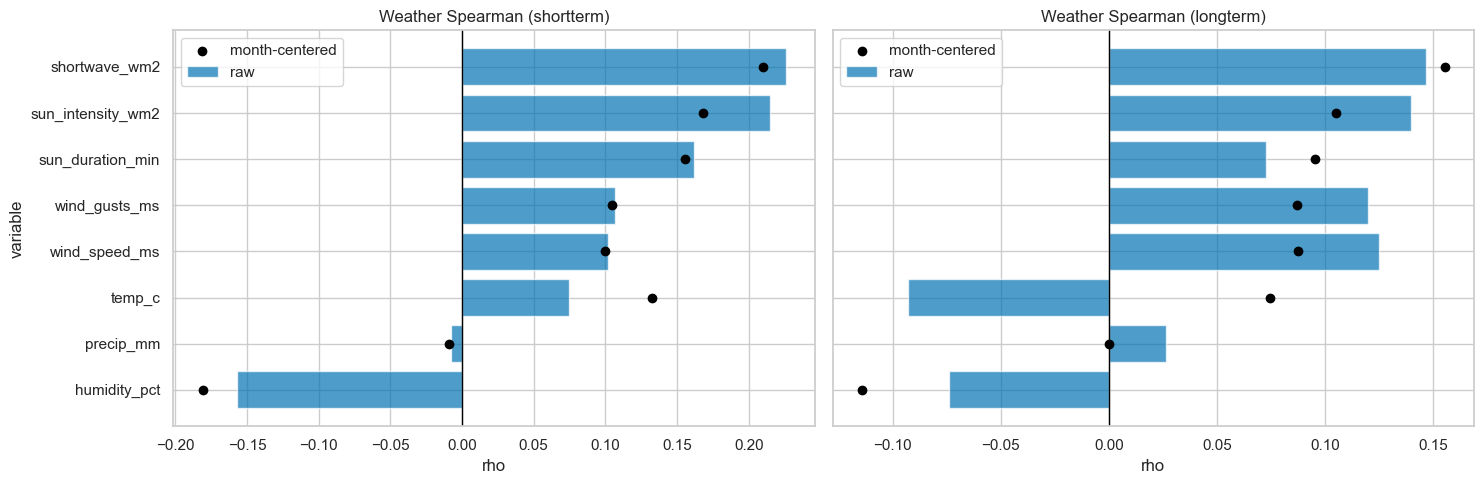

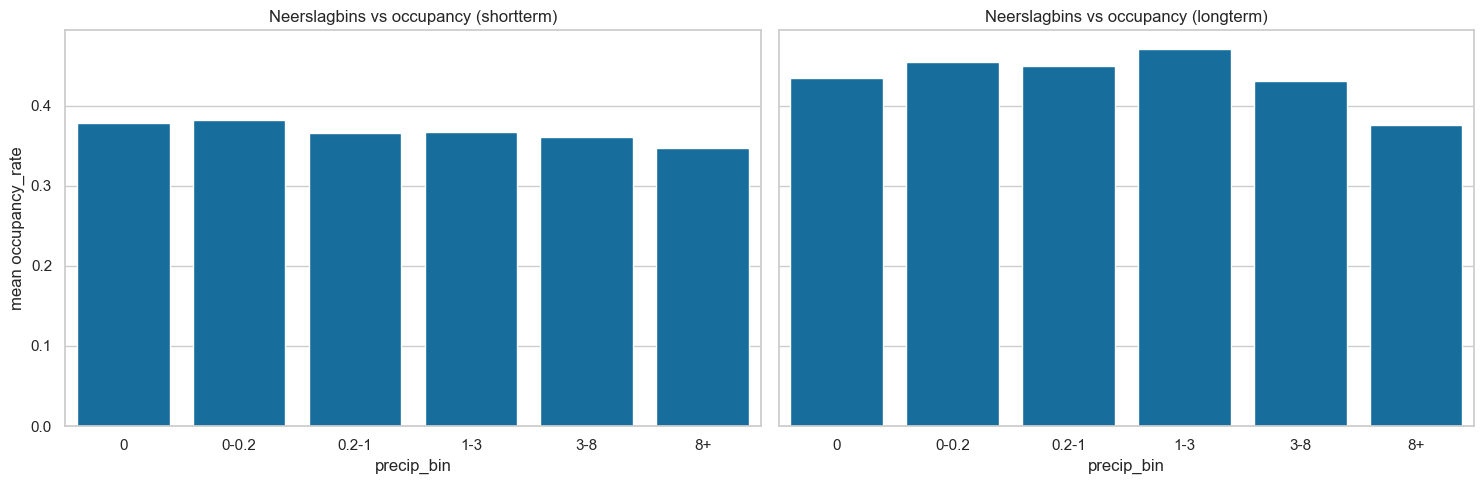

/Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),
/Users/emilevandevoorde/Documents/mp_mechelen_parking_v2/.venv/lib/python3.13/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


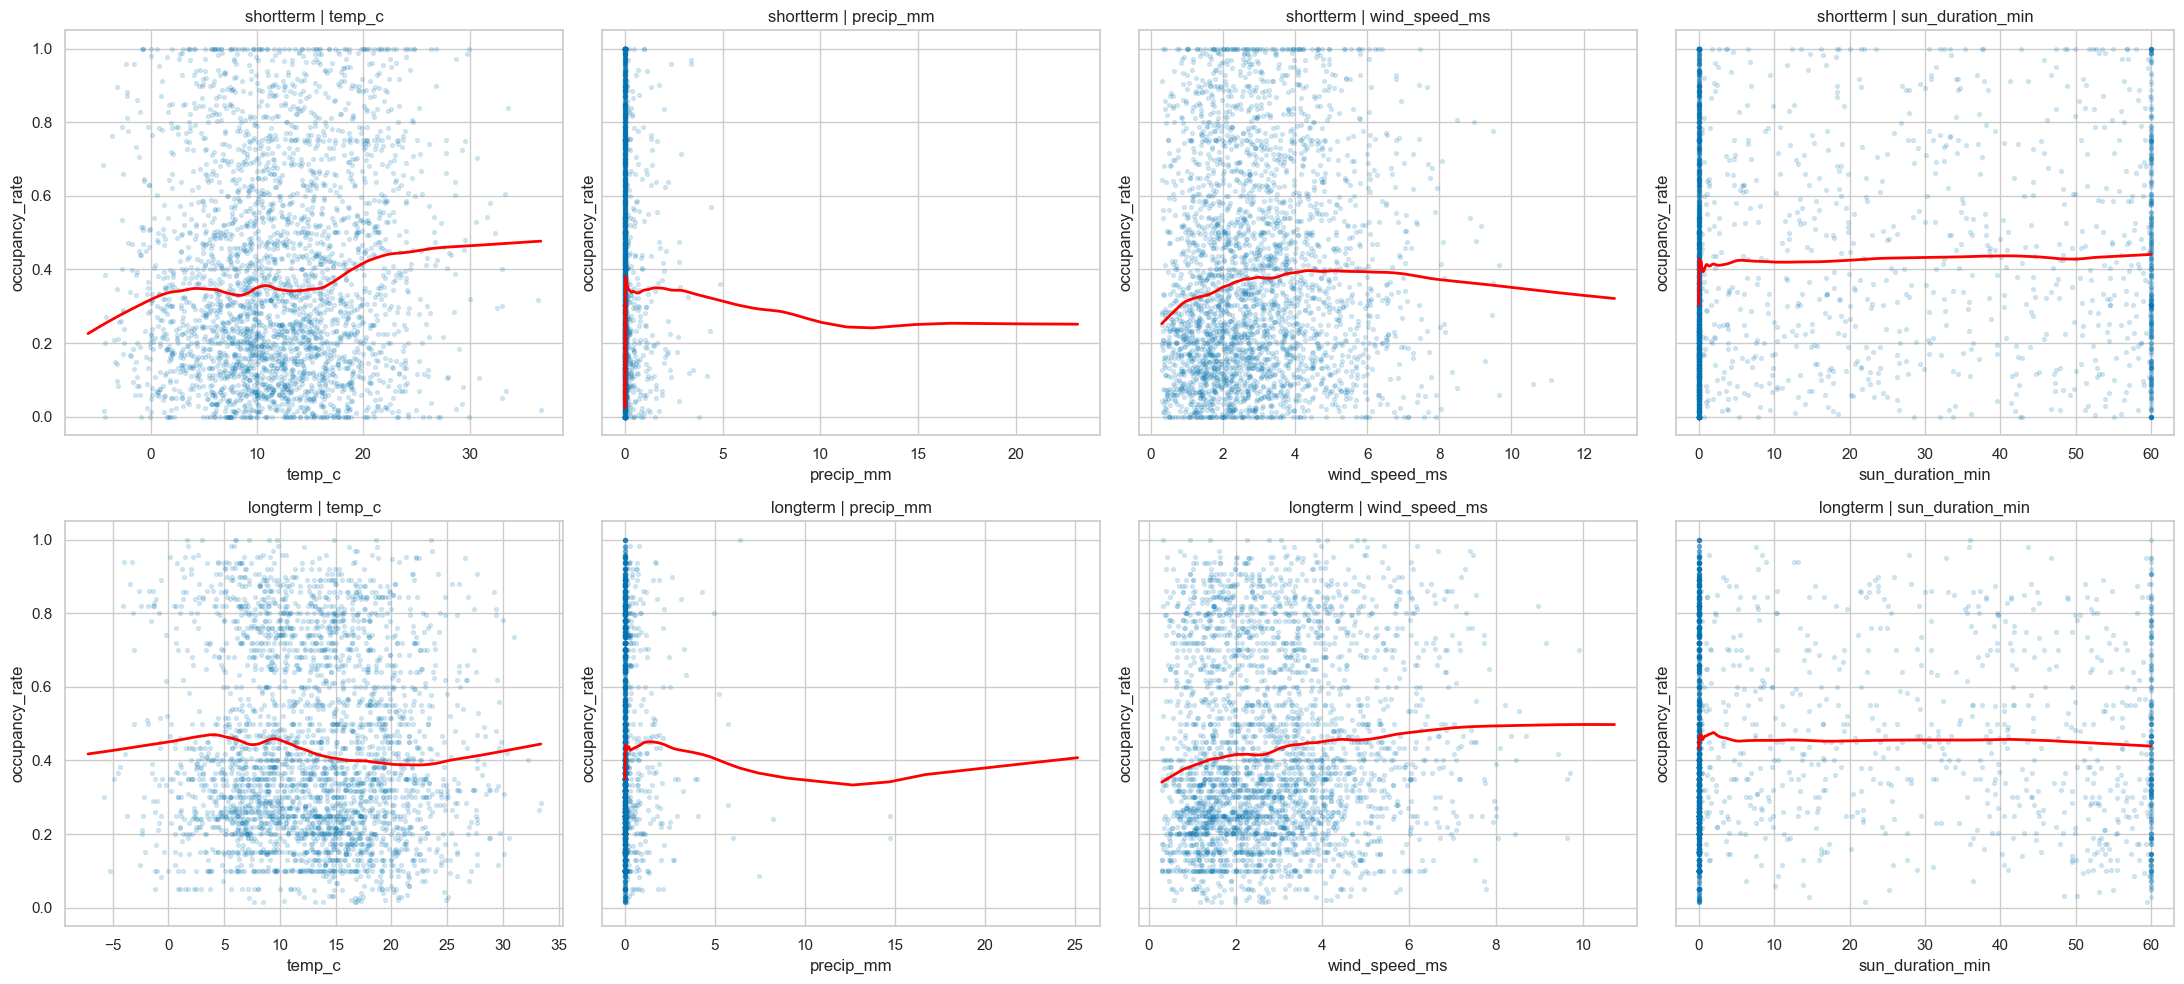

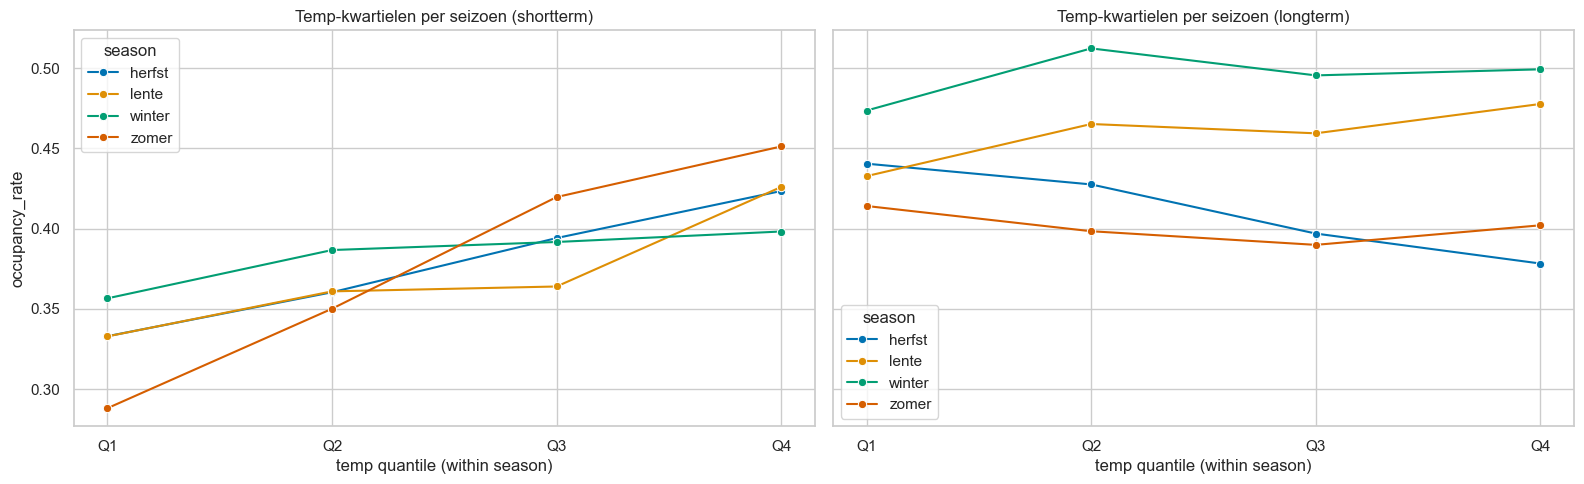

In [4]:
# 2.3 Visualisaties: correlaties, bins, LOWESS en seizoenconditionering

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

plot_df = weather_corr_df.copy()
for i, dataset_label in enumerate(["shortterm", "longterm"]):
    ax = axes[i]
    sub = plot_df.loc[plot_df["dataset_label"] == dataset_label].copy()
    sub = sub.sort_values("rho_raw")

    ax.barh(sub["variable"], sub["rho_raw"], alpha=0.7, label="raw")
    ax.scatter(sub["rho_month_centered"], sub["variable"], color="black", label="month-centered")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Weather Spearman ({dataset_label})")
    ax.set_xlabel("rho")
    if i == 0:
        ax.set_ylabel("variable")
    ax.legend()

plt.tight_layout()
plt.show()

# Precip bins
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    sub = precip_bin_df.loc[precip_bin_df["dataset_label"] == dataset_label]
    sns.barplot(data=sub, x="precip_bin", y="mean", ax=ax)
    ax.set_title(f"Neerslagbins vs occupancy ({dataset_label})")
    ax.set_xlabel("precip_bin")
    ax.set_ylabel("mean occupancy_rate")

plt.tight_layout()
plt.show()

# LOWESS panels
LOWESS_VARS = ["temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min"]

fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharey=True)
for r, dataset_label in enumerate(["shortterm", "longterm"]):
    d = filtered_dfs[dataset_label]
    for c, var in enumerate(LOWESS_VARS):
        ax = axes[r, c]
        smooth = lowess_frame(d, var, frac=0.18)
        sample = d[[var, "occupancy_rate"]].dropna()
        if len(sample) > 3000:
            sample = sample.sample(3000, random_state=42)

        ax.scatter(sample[var], sample["occupancy_rate"], s=8, alpha=0.15)
        if len(smooth) > 0:
            ax.plot(smooth[var], smooth["y_smooth"], color="red", linewidth=2)

        ax.set_title(f"{dataset_label} | {var}")
        ax.set_xlabel(var)
        ax.set_ylabel("occupancy_rate")

plt.tight_layout()
plt.show()

# Temperatuur per seizoen
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    sub = temp_quant_df.loc[temp_quant_df["dataset_label"] == dataset_label]
    sns.lineplot(data=sub, x="temp_q", y="occupancy_rate", hue="season", marker="o", ax=ax)
    ax.set_title(f"Temp-kwartielen per seizoen ({dataset_label})")
    ax.set_xlabel("temp quantile (within season)")

plt.tight_layout()
plt.show()

**Interpretatie**

Weather-signalen zijn aanwezig maar niet uniform. Temperatuur toont duidelijke seizoensinteractie (sterker en positiever in sommige seizoenen, omkeringen in andere contexten), wat lineaire één-coëfficiënt modellering riskant maakt.

Neerslag lijkt overwegend zwak en niet-lineair: lichte neerslag geeft weinig consistent effect, terwijl zwaardere neerslag vaker met lagere bezetting samenvalt. Wind toont in beide datasets een positieve drempelassociatie (hoge windsnelheid/gusts ↔ hogere bezetting). Zonneschijn heeft in deze data geen negatief zomersignaal; integendeel, de associatie is meestal positief.

De month-centered correlaties bevestigen dat confounding belangrijk is: sommige raw associaties verzwakken of veranderen na correctie voor maandstructuur.

**Hypothese status (voorlopig)**
- H-E1: **Partially supported** (zwak maar niet-lineair neerslagsignaal).
- H-E2: **Supported** (temperatuur is context-/seizoensafhankelijk).
- H-E6: **Supported** (sterke wind geassocieerd met hogere bezetting).
- H-E7: **Not supported** (geen consistente negatieve zomerzon-associatie).
- H-E10: **Supported** (weather-effecten verschillen tussen shortterm en longterm).

**Volgende logische stap**
- Calendar-effecten analyseren inclusief tier-heterogeniteit.

## 3. Calendar effects

In [5]:
CALENDAR_FLAGS = [
    "is_any_holiday",
    "is_national_holiday",
    "is_other_holiday",
    "is_school_vacation",
]

calendar_rows = []
calendar_tier_rows = []
for dataset_label, df in filtered_dfs.items():
    # overall
    for flag_col in CALENDAR_FLAGS:
        res = binary_effect(df, flag_col)
        res["dataset_label"] = dataset_label
        res["month_adjusted_delta"] = weighted_month_adjusted_delta(df, flag_col)
        calendar_rows.append(res)

    # tier interacties voor holiday/vacation
    for flag_col in ["is_any_holiday", "is_school_vacation", "is_national_holiday", "is_other_holiday"]:
        for tier, grp in df.groupby("tier_temporal"):
            res = binary_effect(grp, flag_col)
            res["dataset_label"] = dataset_label
            res["tier_temporal"] = tier
            res["month_adjusted_delta"] = weighted_month_adjusted_delta(grp, flag_col)
            calendar_tier_rows.append(res)

calendar_df = pd.DataFrame(calendar_rows)
calendar_tier_df = pd.DataFrame(calendar_tier_rows)

calendar_day_class_df = (
    analysis_df.groupby(["dataset_label", "calendar_day_class"])["occupancy_rate"]
    .agg(["count", "mean", "median", "std"])
    .reset_index()
)

print("Calendar flags overall")
display(calendar_df.round(5))

print("Calendar flags x tier")
display(calendar_tier_df.round(5))

print("calendar_day_class")
display(calendar_day_class_df.sort_values(["dataset_label", "mean"], ascending=[True, False]).round(4))

Calendar flags overall


,flag_col,n_true,n_false,mean_true,mean_false,delta_true_minus_false,dataset_label,month_adjusted_delta
0,is_any_holiday,14544,235893,0.35566,0.38377,-0.02811,shortterm,-0.02976
1,is_national_holiday,7056,243381,0.33228,0.38359,-0.05131,shortterm,-0.05317
2,is_other_holiday,8397,242040,0.36801,0.38263,-0.01462,shortterm,-0.02116
3,is_school_vacation,60216,190221,0.36757,0.38675,-0.01918,shortterm,-0.02135
4,is_any_holiday,3138,43505,0.41540,0.43878,-0.02337,longterm,-0.06357
5,is_national_holiday,1580,45063,0.37740,0.43930,-0.06190,longterm,-0.08941
6,is_other_holiday,1702,44941,0.45441,0.43655,0.01785,longterm,-0.03222
7,is_school_vacation,14195,32448,0.39979,0.45358,-0.05379,longterm,-0.04004


Calendar flags x tier


,flag_col,n_true,n_false,mean_true,mean_false,delta_true_minus_false,dataset_label,tier_temporal,month_adjusted_delta
0,is_any_holiday,8027,127902,0.41674,0.44829,-0.03155,shortterm,centrum,-0.03480
1,is_any_holiday,6517,107991,0.28043,0.30736,-0.02692,shortterm,vesten_of_rand,-0.02548
2,is_school_vacation,31124,104805,0.43820,0.44887,-0.01067,shortterm,centrum,-0.02298
3,is_school_vacation,29092,85416,0.29201,0.31053,-0.01852,shortterm,vesten_of_rand,-0.00738
4,is_national_holiday,3903,132026,0.39373,0.44799,-0.05426,shortterm,centrum,-0.06031
5,is_national_holiday,3153,111355,0.25621,0.30723,-0.05102,shortterm,vesten_of_rand,-0.04790
6,is_other_holiday,4602,131327,0.42968,0.44702,-0.01734,shortterm,centrum,-0.02713
7,is_other_holiday,3795,110713,0.29323,0.30626,-0.01302,shortterm,vesten_of_rand,-0.01598
8,is_any_holiday,1709,23972,0.44897,0.48238,-0.03341,longterm,centrum,-0.06252
9,is_any_holiday,1429,19533,0.37526,0.38526,-0.01001,longterm,vesten_of_rand,-0.06743


calendar_day_class


,dataset_label,calendar_day_class,count,mean,median,std
2,longterm,regular_day,21972,0.4698,0.4167,0.2653
1,longterm,other_holiday,1558,0.4539,0.3833,0.2657
4,longterm,weekend,8998,0.4150,0.3500,0.2376
3,longterm,school_vacation,12535,0.4016,0.3400,0.2365
0,longterm,national_holiday,1580,0.3774,0.3000,0.2391
9,shortterm,weekend,51040,0.3953,0.3392,0.2850
7,shortterm,regular_day,132160,0.3843,0.3317,0.2784
6,shortterm,other_holiday,7488,0.3777,0.3030,0.2826
8,shortterm,school_vacation,52693,0.3713,0.3005,0.2778
5,shortterm,national_holiday,7056,0.3323,0.2638,0.2511


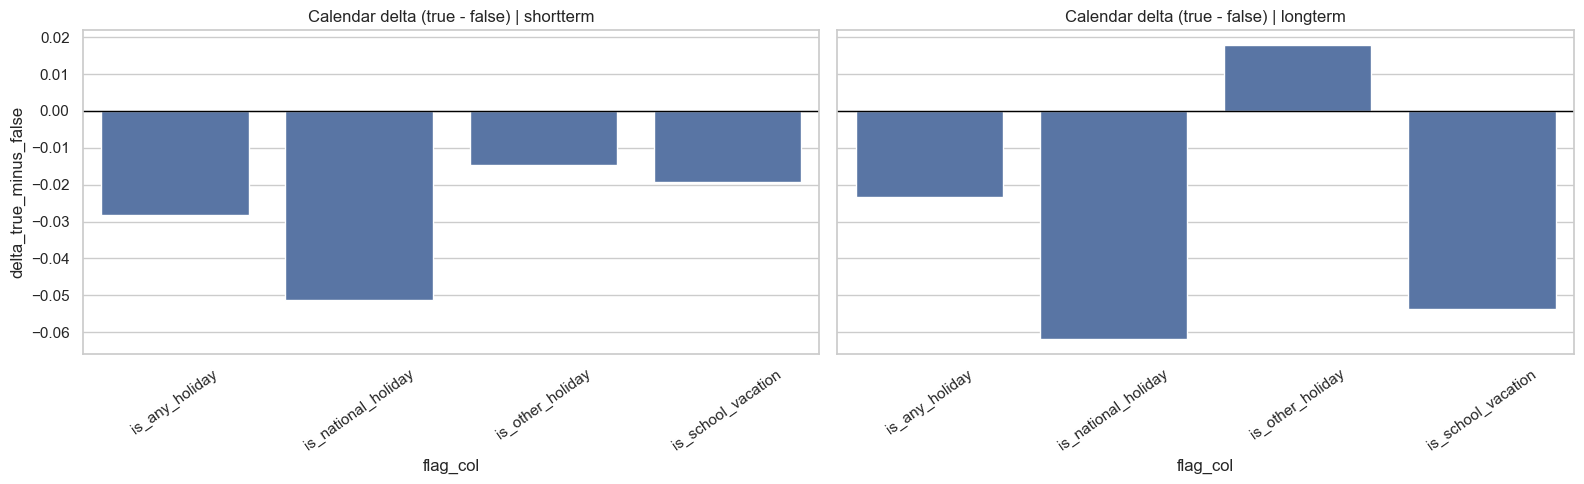

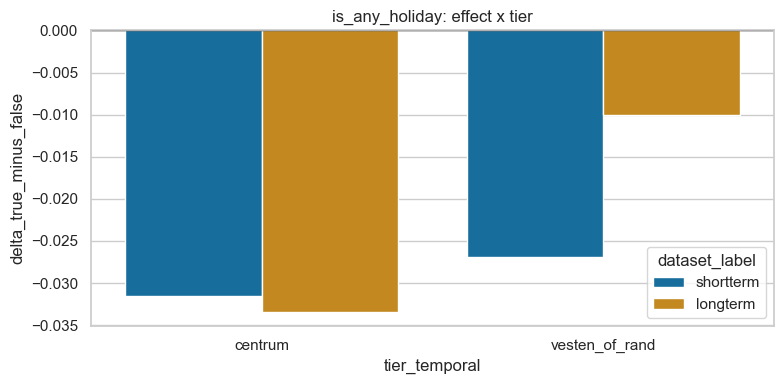

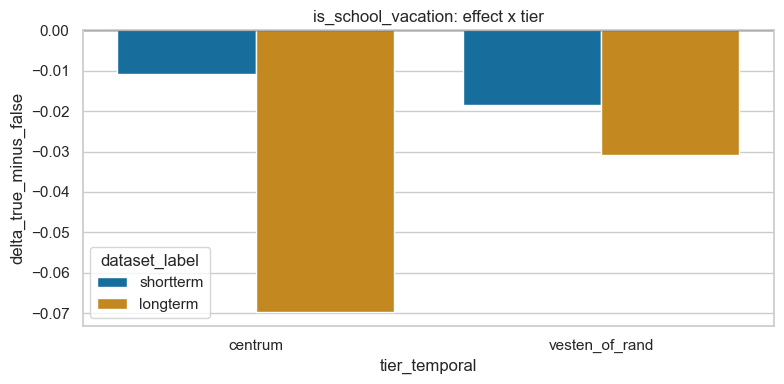

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    sub = calendar_df.loc[calendar_df["dataset_label"] == dataset_label].copy()
    sns.barplot(data=sub, x="flag_col", y="delta_true_minus_false", color="#4c72b0", ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Calendar delta (true - false) | {dataset_label}")
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

for flag in ["is_any_holiday", "is_school_vacation"]:
    plt.figure(figsize=(8, 4))
    sub = calendar_tier_df.loc[calendar_tier_df["flag_col"] == flag].copy()
    sns.barplot(data=sub, x="tier_temporal", y="delta_true_minus_false", hue="dataset_label")
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"{flag}: effect x tier")
    plt.tight_layout()
    plt.show()

**Interpretatie**

Holiday- en vacation-dagen tonen overwegend lagere bezetting dan referentiedagen, met duidelijke verschillen in grootteorde per tier en dataset. National holidays hebben gemiddeld sterkere negatieve associaties dan `other_holiday`.

De month-adjusted deltas temperen sommige effecten, wat wijst op gedeeltelijke seizoensconfounding. Toch blijven meerdere holiday/vacation-signalen robuust negatief.

**Hypothese status (voorlopig)**
- H-E4: **Supported** (holiday-effecten verschillen per tier).
- H-E8: **Supported** (schoolvakantie-effecten verschillen tussen centrum en outer).
- H-E11: **Verder ondersteund** (confoundingcontrole verandert effectgrootten).

**Volgende logische stap**
- Eventeffecten verdiepen (eventtypes, schaal, concurrentie, kickoffvensters).

## 4. Event effects

In [7]:
EVENT_FLAGS = [
    "is_event_day",
    "is_football_day",
    "is_sport_day",
    "is_festival_day",
    "is_procession_day",
    "is_kermis_day",
    "is_markt_day",
    "is_carnival_day",
    "is_other_day",
]

# 4.1 Event flags overall en month-adjusted
event_rows = []
for dataset_label, df in filtered_dfs.items():
    for flag_col in EVENT_FLAGS:
        res = binary_effect(df, flag_col)
        res["dataset_label"] = dataset_label
        res["month_adjusted_delta"] = weighted_month_adjusted_delta(df, flag_col)
        event_rows.append(res)

event_df = pd.DataFrame(event_rows)

# 4.2 Event x tier
event_tier_rows = []
for dataset_label, df in filtered_dfs.items():
    for flag_col in ["is_event_day", "is_football_day", "is_sport_day", "is_festival_day"]:
        for tier, grp in df.groupby("tier_temporal"):
            res = binary_effect(grp, flag_col)
            res["dataset_label"] = dataset_label
            res["tier_temporal"] = tier
            res["month_adjusted_delta"] = weighted_month_adjusted_delta(grp, flag_col)
            event_tier_rows.append(res)

event_tier_df = pd.DataFrame(event_tier_rows)

# 4.3 Event scale / concurrent events
event_scale_rows = []
for dataset_label, df in filtered_dfs.items():
    for tier, grp in df.groupby("tier_temporal"):
        t_scale = grp.groupby("event_scale_max")["occupancy_rate"].agg(["count", "mean"]).reset_index()
        t_scale["dataset_label"] = dataset_label
        t_scale["tier_temporal"] = tier
        t_scale["feature"] = "event_scale_max"
        event_scale_rows.append(t_scale)

        t_conc = grp.groupby("n_concurrent_events")["occupancy_rate"].agg(["count", "mean"]).reset_index()
        t_conc["dataset_label"] = dataset_label
        t_conc["tier_temporal"] = tier
        t_conc["feature"] = "n_concurrent_events"
        event_scale_rows.append(t_conc)

event_scale_df = pd.concat(event_scale_rows, ignore_index=True)

# Spearman op event-uren
event_monotonic_rows = []
for dataset_label, df in filtered_dfs.items():
    ev = df.loc[as_flag(df["is_event_day"])].copy()
    if len(ev) < 100:
        continue

    rho_scale, p_scale, n_scale = spearman_safe(ev, "event_scale_max")
    rho_conc, p_conc, n_conc = spearman_safe(ev, "n_concurrent_events")

    event_monotonic_rows.append(
        {
            "dataset_label": dataset_label,
            "tier_temporal": "all",
            "rho_scale": rho_scale,
            "p_scale": p_scale,
            "rho_concurrent": rho_conc,
            "p_concurrent": p_conc,
            "n_event_rows": int(len(ev)),
        }
    )

    for tier, grp in ev.groupby("tier_temporal"):
        rho_scale_t, p_scale_t, _ = spearman_safe(grp, "event_scale_max")
        rho_conc_t, p_conc_t, _ = spearman_safe(grp, "n_concurrent_events")
        event_monotonic_rows.append(
            {
                "dataset_label": dataset_label,
                "tier_temporal": tier,
                "rho_scale": rho_scale_t,
                "p_scale": p_scale_t,
                "rho_concurrent": rho_conc_t,
                "p_concurrent": p_conc_t,
                "n_event_rows": int(len(grp)),
            }
        )

event_monotonic_df = pd.DataFrame(event_monotonic_rows)

print("Eventeffecten overall")
display(event_df.round(5))

print("Event x tier")
display(event_tier_df.round(5))

print("Event scale / concurrent summary")
display(event_scale_df.round(4))

print("Monotoniciteitscheck op eventrows")
display(event_monotonic_df.round(6))

Eventeffecten overall


,flag_col,n_true,n_false,mean_true,mean_false,delta_true_minus_false,dataset_label,month_adjusted_delta
0,is_event_day,61801,188636,0.38989,0.37960,0.01029,shortterm,0.00607
1,is_football_day,8696,241741,0.38914,0.38189,0.00725,shortterm,0.00063
2,is_sport_day,11612,238825,0.37137,0.38266,-0.01129,shortterm,-0.02245
3,is_festival_day,7386,243051,0.39779,0.38167,0.01612,shortterm,0.00666
4,is_procession_day,1598,248839,0.40320,0.38201,0.02120,shortterm,0.01469
5,is_kermis_day,26929,223508,0.40349,0.37957,0.02392,shortterm,0.00681
6,is_markt_day,5916,244521,0.36259,0.38261,-0.02003,shortterm,-0.01336
7,is_carnival_day,2854,247583,0.36129,0.38238,-0.02109,shortterm,-0.01583
8,is_other_day,10048,240389,0.37649,0.38238,-0.00589,shortterm,-0.01142
9,is_event_day,14782,31861,0.40166,0.45370,-0.05204,longterm,-0.02575


Event x tier


,flag_col,n_true,n_false,mean_true,mean_false,delta_true_minus_false,dataset_label,tier_temporal,month_adjusted_delta
0,is_event_day,32350,103579,0.44655,0.44639,0.00016,shortterm,centrum,-0.01632
1,is_event_day,29451,85057,0.32766,0.29826,0.02940,shortterm,vesten_of_rand,0.04027
2,is_football_day,4616,131313,0.42961,0.44702,-0.01741,shortterm,centrum,-0.03374
3,is_football_day,4080,110428,0.34334,0.30444,0.03890,shortterm,vesten_of_rand,0.04629
4,is_sport_day,6134,129795,0.41999,0.44768,-0.02769,shortterm,centrum,-0.04986
5,is_sport_day,5478,109030,0.31693,0.30527,0.01166,shortterm,vesten_of_rand,0.01037
6,is_festival_day,3514,132415,0.49663,0.44510,0.05153,shortterm,centrum,0.02682
7,is_festival_day,3872,110636,0.30808,0.30575,0.00233,shortterm,vesten_of_rand,0.00278
8,is_event_day,7924,17757,0.43840,0.49880,-0.06040,longterm,centrum,-0.03546
9,is_event_day,6858,14104,0.35921,0.39692,-0.03771,longterm,vesten_of_rand,-0.01493


Event scale / concurrent summary


,event_scale_max,count,mean,dataset_label,tier_temporal,feature,n_concurrent_events
0,0.0,103579,0.4464,shortterm,centrum,event_scale_max,NaN
1,1.0,6262,0.4163,shortterm,centrum,event_scale_max,NaN
2,2.0,24235,0.4517,shortterm,centrum,event_scale_max,NaN
3,3.0,1853,0.4821,shortterm,centrum,event_scale_max,NaN
4,NaN,103579,0.4464,shortterm,centrum,n_concurrent_events,0.0
5,NaN,26458,0.4537,shortterm,centrum,n_concurrent_events,1.0
6,NaN,4938,0.4061,shortterm,centrum,n_concurrent_events,2.0
7,NaN,954,0.4566,shortterm,centrum,n_concurrent_events,3.0
8,0.0,85057,0.2983,shortterm,vesten_of_rand,event_scale_max,NaN
9,1.0,5088,0.3458,shortterm,vesten_of_rand,event_scale_max,NaN


Monotoniciteitscheck op eventrows


,dataset_label,tier_temporal,rho_scale,p_scale,rho_concurrent,p_concurrent,n_event_rows
0,shortterm,all,0.016328,0.000049,-0.019041,0.000002,61801
1,shortterm,centrum,0.051049,0.000000,-0.055499,0.000000,32350
2,shortterm,vesten_of_rand,-0.010826,0.063190,0.027670,0.000002,29451
3,longterm,all,-0.043290,0.000000,-0.032167,0.000092,14782
4,longterm,centrum,-0.060772,0.000000,-0.059259,0.000000,7924
5,longterm,vesten_of_rand,-0.023975,0.047101,-0.014287,0.236796,6858


In [8]:
# 4.4 Voor/na-eventvensters rond football_kickoff_hour
football_phase_rows = []
for dataset_label, df in filtered_dfs.items():
    if "football_kickoff_hour" not in df.columns:
        continue

    kickoff = pd.to_numeric(df["football_kickoff_hour"], errors="coerce")
    mask = kickoff.notna()
    if int(mask.sum()) < 100:
        continue

    w = df.loc[mask, ["occupancy_rate", "hour"]].copy()
    w["kickoff_hour"] = kickoff[mask].values
    w["delta_h"] = w["hour"] - w["kickoff_hour"]
    w = w.loc[w["delta_h"].between(-8, 12)].copy()

    bins = [-8, -3, -1, 0.5, 2.5, 6, 12]
    labels = [
        "pre_far(-8,-3]",
        "pre_near(-3,-1]",
        "kick_window(-1,0.5]",
        "post_short(0.5,2.5]",
        "post_mid(2.5,6]",
        "post_late(6,12]",
    ]
    w["phase"] = pd.cut(w["delta_h"], bins=bins, labels=labels)

    phase_tbl = w.groupby("phase", observed=True)["occupancy_rate"].agg(["count", "mean", "median"]).reset_index()
    phase_tbl["dataset_label"] = dataset_label
    football_phase_rows.append(phase_tbl)

football_phase_df = pd.concat(football_phase_rows, ignore_index=True) if football_phase_rows else pd.DataFrame()

# 4.5 Daily lead/lag rond eventdagen
event_daily_rows = []
for dataset_label, df in filtered_dfs.items():
    daily = (
        df.groupby(["parking_id", "date_only"])
        .agg(occ=("occupancy_rate", "mean"), event=("is_event_day", "max"))
        .reset_index()
        .sort_values(["parking_id", "date_only"])
    )
    daily["event"] = as_flag(daily["event"])

    near = daily["event"].copy()
    for k in [1, 2]:
        near |= daily.groupby("parking_id")["event"].shift(k).fillna(False)
        near |= daily.groupby("parking_id")["event"].shift(-k).fillna(False)

    baseline = ~near

    for lag in [-2, -1, 0, 1, 2]:
        # Flag dagen die lag-uren van eventdag liggen
        if lag == 0:
            is_window = daily["event"]
        else:
            is_window = daily.groupby("parking_id")["event"].shift(-lag).fillna(False)

        n_win = int(is_window.sum())
        n_base = int(baseline.sum())
        if n_win < 30 or n_base < 30:
            continue

        delta = float(daily.loc[is_window, "occ"].mean() - daily.loc[baseline, "occ"].mean())
        event_daily_rows.append(
            {
                "dataset_label": dataset_label,
                "lag_days_vs_event": lag,
                "n_window_days": n_win,
                "n_baseline_days": n_base,
                "delta_vs_far_non_event_days": delta,
            }
        )

event_daily_df = pd.DataFrame(event_daily_rows)

print("Football kickoff phases")
display(football_phase_df.round(4))

print("Event daily lead/lag")
display(event_daily_df.round(4))

Football kickoff phases


,phase,count,mean,median,dataset_label
0,"pre_far(-8,-3]",1810,0.4719,0.4233,shortterm
1,"pre_near(-3,-1]",726,0.4556,0.4053,shortterm
2,"kick_window(-1,0.5]",444,0.4501,0.3899,shortterm
3,"post_short(0.5,2.5]",738,0.4180,0.3648,shortterm
4,"post_mid(2.5,6]",874,0.3529,0.2963,shortterm
5,"post_late(6,12]",102,0.2320,0.1741,shortterm
6,"pre_far(-8,-3]",373,0.4258,0.3833,longterm
7,"pre_near(-3,-1]",152,0.4264,0.4000,longterm
8,"kick_window(-1,0.5]",94,0.4138,0.3583,longterm
9,"post_short(0.5,2.5]",151,0.3974,0.3167,longterm


Event daily lead/lag


,dataset_label,lag_days_vs_event,n_window_days,n_baseline_days,delta_vs_far_non_event_days
0,shortterm,-2,2882,5692,-0.0150
1,shortterm,-1,2882,5692,-0.0119
2,shortterm,0,2882,5692,-0.0040
3,shortterm,1,2881,5692,0.0026
4,shortterm,2,2879,5692,-0.0043
5,longterm,-2,629,593,-0.0430
6,longterm,-1,629,593,-0.0584
7,longterm,0,629,593,-0.0678
8,longterm,1,629,593,-0.0553
9,longterm,2,625,593,-0.0491


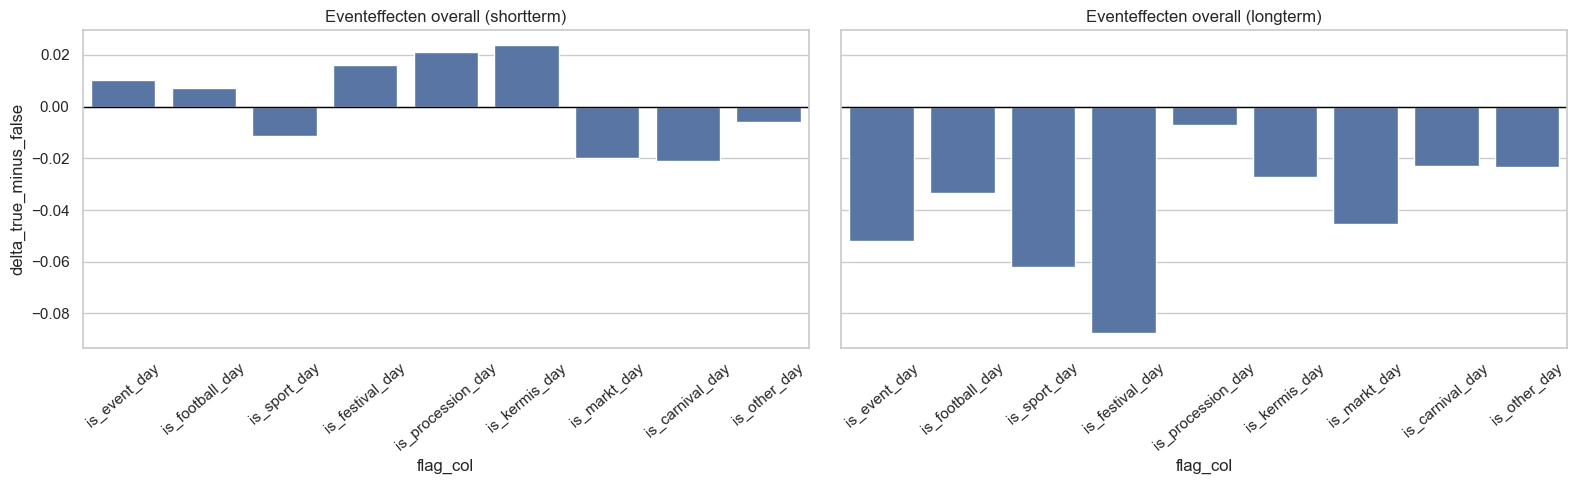

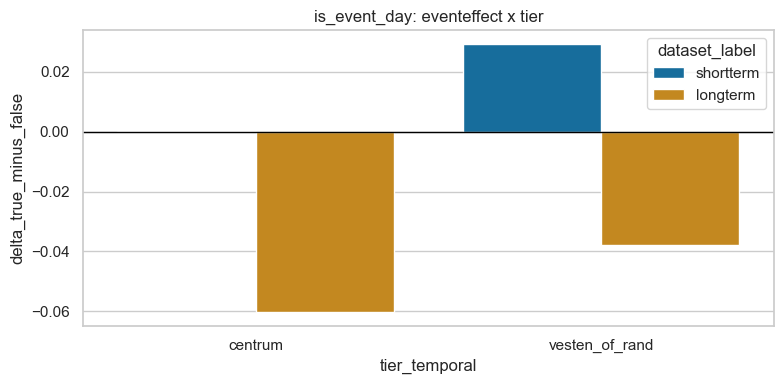

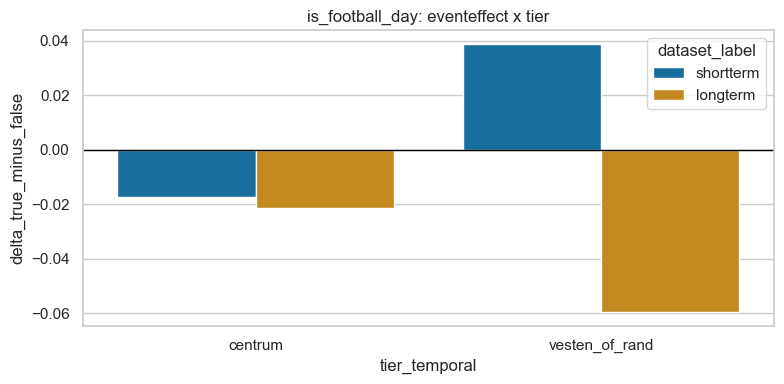

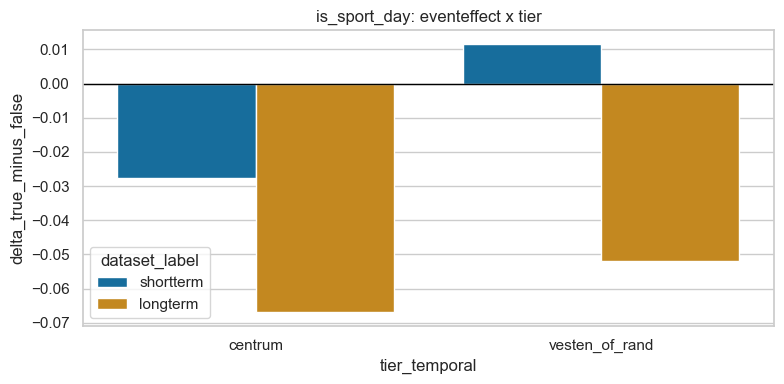

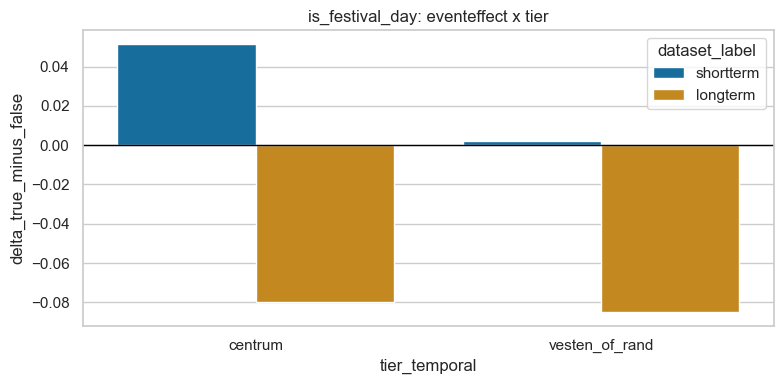

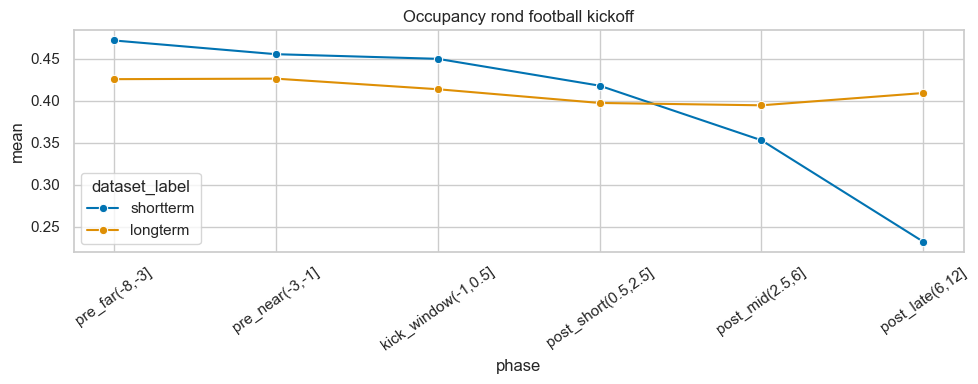

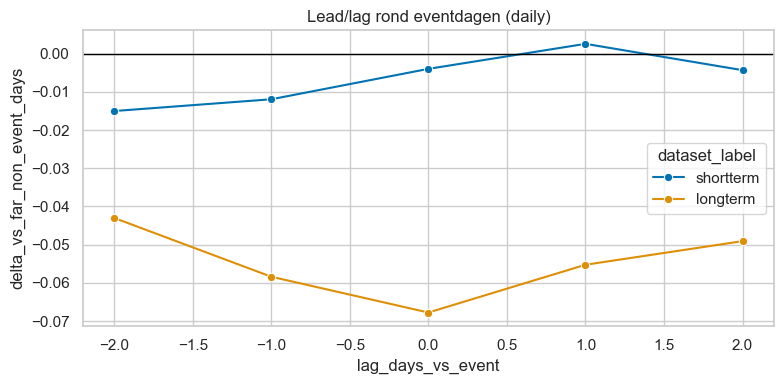

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

for ax, dataset_label in zip(axes, ["shortterm", "longterm"]):
    sub = event_df.loc[event_df["dataset_label"] == dataset_label].copy()
    sns.barplot(data=sub, x="flag_col", y="delta_true_minus_false", color="#4c72b0", ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"Eventeffecten overall ({dataset_label})")
    ax.tick_params(axis="x", rotation=40)

plt.tight_layout()
plt.show()

for flag_col in ["is_event_day", "is_football_day", "is_sport_day", "is_festival_day"]:
    plt.figure(figsize=(8, 4))
    sub = event_tier_df.loc[event_tier_df["flag_col"] == flag_col].copy()
    sns.barplot(data=sub, x="tier_temporal", y="delta_true_minus_false", hue="dataset_label")
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"{flag_col}: eventeffect x tier")
    plt.tight_layout()
    plt.show()

if not football_phase_df.empty:
    plt.figure(figsize=(10, 4))
    sns.lineplot(data=football_phase_df, x="phase", y="mean", hue="dataset_label", marker="o")
    plt.xticks(rotation=35)
    plt.title("Occupancy rond football kickoff")
    plt.tight_layout()
    plt.show()

plt.figure(figsize=(8, 4))
sns.lineplot(data=event_daily_df, x="lag_days_vs_event", y="delta_vs_far_non_event_days", hue="dataset_label", marker="o")
plt.axhline(0, color="black", linewidth=1)
plt.title("Lead/lag rond eventdagen (daily)")
plt.tight_layout()
plt.show()

**Interpretatie**

Eventeffecten zijn heterogeen: in shortterm zijn sommige eventtypes positief en andere negatief, terwijl in longterm eventdagen vaker negatief uitvallen. Na maandcorrectie blijven effecten bestaan maar kleiner, wat seizoens/eventmix-confounding bevestigt.

Voor football-kickoffvensters is er aanwijzing voor hogere bezetting vóór kickoff en gefaseerde afname nadien (duidelijker in shortterm). Dat patroon generaliseert echter niet automatisch naar alle eventtypes of naar longterm.

Eventomvang (`event_scale_max`) en gelijktijdige events (`n_concurrent_events`) tonen dataset- en tierafhankelijke relaties. Dit pleit tegen één globale event-intensiteitsfunctie.

**Hypothese status (voorlopig)**
- H-E3: **Partially supported** (kickoffvenster toont pre/post-dynamiek, maar event-dagpatroon is niet uniform).
- H-E9: **Partially supported** (schaaleffect vooral in longterm en contextafhankelijk).
- H-E10: **Verder ondersteund** (eventassociaties verschillen duidelijk tussen datasets).
- H-E11: **Verder ondersteund** (month-adjusted effecten en confidence-structuur tonen confoundingrisico).

**Volgende logische stap**
- Interacties systematisch samenvatten: event × tier, holiday × tier, weather × season, weather × dataset.

## 5. Interactieanalyse

In [10]:
# 5.1 Weather x season: Q4-Q1 effect binnen seizoen
weather_interaction_rows = []
for dataset_label, df in filtered_dfs.items():
    for var in ["temp_c", "precip_mm", "wind_speed_ms", "sun_duration_min", "humidity_pct"]:
        for season, grp in df[["season", var, "occupancy_rate"]].dropna().groupby("season"):
            if len(grp) < 300:
                continue

            g = grp.copy()
            try:
                g["qbin"] = pd.qcut(g[var], 4, duplicates="drop")
            except ValueError:
                continue

            means = g.groupby("qbin", observed=True)["occupancy_rate"].mean().sort_index()
            if len(means) < 2:
                continue

            q1 = float(means.iloc[0])
            q4 = float(means.iloc[-1])
            weather_interaction_rows.append(
                {
                    "dataset_label": dataset_label,
                    "season": season,
                    "weather_var": var,
                    "q1_mean": q1,
                    "q4_mean": q4,
                    "delta_q4_minus_q1": q4 - q1,
                    "n_bins": int(len(means)),
                }
            )

weather_interaction_df = pd.DataFrame(weather_interaction_rows)

# 5.2 Holiday x tier en vacation x tier (compacte extract)
holiday_tier_extract = calendar_tier_df.loc[
    calendar_tier_df["flag_col"].isin(["is_any_holiday", "is_school_vacation", "is_national_holiday", "is_other_holiday"])
].copy()

# 5.3 Event x tier (compacte extract)
event_tier_extract = event_tier_df.loc[
    event_tier_df["flag_col"].isin(["is_event_day", "is_football_day", "is_sport_day", "is_festival_day"])
].copy()

print("Weather x season (Q4-Q1)")
display(weather_interaction_df.round(5))

print("Holiday x tier")
display(holiday_tier_extract.round(5))

print("Event x tier")
display(event_tier_extract.round(5))

Weather x season (Q4-Q1)


,dataset_label,season,weather_var,q1_mean,q4_mean,delta_q4_minus_q1,n_bins
0,shortterm,herfst,temp_c,0.33306,0.42344,0.09038,4
1,shortterm,lente,temp_c,0.33293,0.42597,0.09304,4
2,shortterm,winter,temp_c,0.35663,0.39823,0.04160,4
3,shortterm,zomer,temp_c,0.28824,0.45118,0.16294,4
4,shortterm,herfst,wind_speed_ms,0.35299,0.40114,0.04814,4
5,shortterm,lente,wind_speed_ms,0.31242,0.40775,0.09532,4
6,shortterm,winter,wind_speed_ms,0.36594,0.40196,0.03602,4
7,shortterm,zomer,wind_speed_ms,0.29862,0.44338,0.14476,4
8,shortterm,herfst,sun_duration_min,0.34770,0.46803,0.12033,2
9,shortterm,lente,sun_duration_min,0.35003,0.43377,0.08374,2


Holiday x tier


,flag_col,n_true,n_false,mean_true,mean_false,delta_true_minus_false,dataset_label,tier_temporal,month_adjusted_delta
0,is_any_holiday,8027,127902,0.41674,0.44829,-0.03155,shortterm,centrum,-0.03480
1,is_any_holiday,6517,107991,0.28043,0.30736,-0.02692,shortterm,vesten_of_rand,-0.02548
2,is_school_vacation,31124,104805,0.43820,0.44887,-0.01067,shortterm,centrum,-0.02298
3,is_school_vacation,29092,85416,0.29201,0.31053,-0.01852,shortterm,vesten_of_rand,-0.00738
4,is_national_holiday,3903,132026,0.39373,0.44799,-0.05426,shortterm,centrum,-0.06031
5,is_national_holiday,3153,111355,0.25621,0.30723,-0.05102,shortterm,vesten_of_rand,-0.04790
6,is_other_holiday,4602,131327,0.42968,0.44702,-0.01734,shortterm,centrum,-0.02713
7,is_other_holiday,3795,110713,0.29323,0.30626,-0.01302,shortterm,vesten_of_rand,-0.01598
8,is_any_holiday,1709,23972,0.44897,0.48238,-0.03341,longterm,centrum,-0.06252
9,is_any_holiday,1429,19533,0.37526,0.38526,-0.01001,longterm,vesten_of_rand,-0.06743


Event x tier


,flag_col,n_true,n_false,mean_true,mean_false,delta_true_minus_false,dataset_label,tier_temporal,month_adjusted_delta
0,is_event_day,32350,103579,0.44655,0.44639,0.00016,shortterm,centrum,-0.01632
1,is_event_day,29451,85057,0.32766,0.29826,0.02940,shortterm,vesten_of_rand,0.04027
2,is_football_day,4616,131313,0.42961,0.44702,-0.01741,shortterm,centrum,-0.03374
3,is_football_day,4080,110428,0.34334,0.30444,0.03890,shortterm,vesten_of_rand,0.04629
4,is_sport_day,6134,129795,0.41999,0.44768,-0.02769,shortterm,centrum,-0.04986
5,is_sport_day,5478,109030,0.31693,0.30527,0.01166,shortterm,vesten_of_rand,0.01037
6,is_festival_day,3514,132415,0.49663,0.44510,0.05153,shortterm,centrum,0.02682
7,is_festival_day,3872,110636,0.30808,0.30575,0.00233,shortterm,vesten_of_rand,0.00278
8,is_event_day,7924,17757,0.43840,0.49880,-0.06040,longterm,centrum,-0.03546
9,is_event_day,6858,14104,0.35921,0.39692,-0.03771,longterm,vesten_of_rand,-0.01493


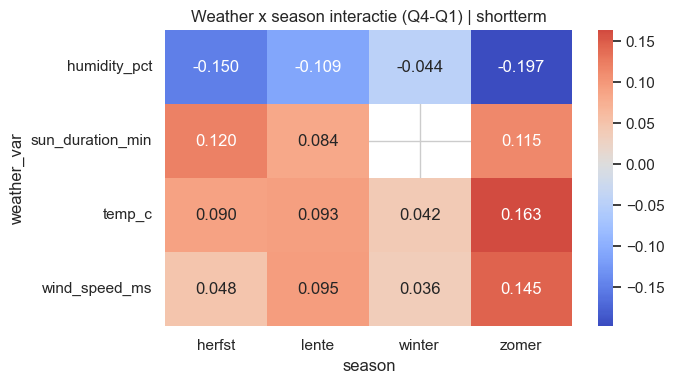

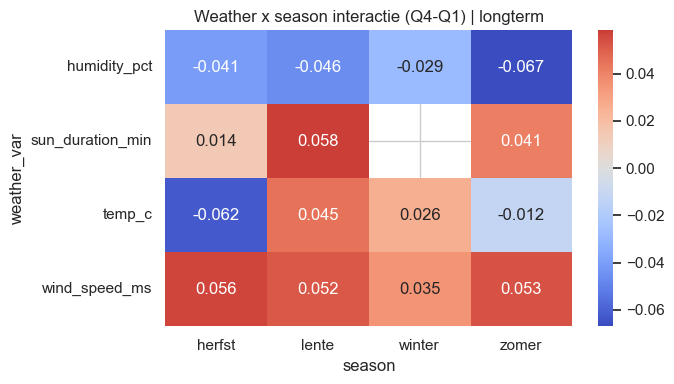

In [11]:
# Heatmap van weather x season interacties
for dataset_label in ["shortterm", "longterm"]:
    sub = weather_interaction_df.loc[weather_interaction_df["dataset_label"] == dataset_label]
    pivot = sub.pivot(index="weather_var", columns="season", values="delta_q4_minus_q1")

    plt.figure(figsize=(7, 4))
    sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".3f")
    plt.title(f"Weather x season interactie (Q4-Q1) | {dataset_label}")
    plt.tight_layout()
    plt.show()

**Interpretatie**

Interactieanalyse bevestigt dat externe effecten contextafhankelijk zijn. Weather-effecten veranderen per seizoen en dataset, terwijl holiday- en eventeffecten per tier kunnen draaien in grootte en soms in richting.

Dat betekent dat feature engineering best expliciete interactietermen gebruikt in plaats van alleen marginale hoofdtermen.

**Volgende logische stap**
- Driver-per-driver samenvatten (richting, vorm, stabiliteit, feature-bruikbaarheid) en hypotheses formeel afsluiten.

## 6. Driver report voor feature engineering

In [12]:
driver_report = pd.DataFrame(
    [
        {
            "driver": "precip_mm",
            "effectrichting": "overwegend zwak negatief (na month-correctie bijna nul in longterm)",
            "vorm": "niet-lineair/drempelmatig (extreme neerslag afwijkend)",
            "stabiliteit_segmenten": "laag-matig; verschilt per dataset/season",
            "feature_engineering_use": "bins/thresholds nuttiger dan lineaire term",
        },
        {
            "driver": "temp_c",
            "effectrichting": "seizoensafhankelijk; positief in meerdere contexten, omkeringen mogelijk",
            "vorm": "interactief + deels niet-lineair",
            "stabiliteit_segmenten": "matig; duidelijk season- en datasetafhankelijk",
            "feature_engineering_use": "temp × season / temp × month (eventueel splines of bins)",
        },
        {
            "driver": "wind_speed_ms / wind_gusts_ms",
            "effectrichting": "positief (sterkere wind ↔ hogere occupancy)",
            "vorm": "drempelmatig (p90-effect duidelijk)",
            "stabiliteit_segmenten": "matig-goed over datasets",
            "feature_engineering_use": "high-wind indicators + continue component",
        },
        {
            "driver": "sun_duration/radiation",
            "effectrichting": "meestal positief in deze data",
            "vorm": "niet-lineair mogelijk, maar geen negatief zomerpatroon",
            "stabiliteit_segmenten": "matig; datasetafhankelijk in grootte",
            "feature_engineering_use": "continue + season interacties; geen vaste negatieve assumptie",
        },
        {
            "driver": "humidity_pct",
            "effectrichting": "negatief",
            "vorm": "grotendeels monotoon associatief",
            "stabiliteit_segmenten": "matig-goed",
            "feature_engineering_use": "continue term + mogelijke interactie met temp",
        },
        {
            "driver": "holiday flags",
            "effectrichting": "meestal negatief t.o.v. non-holiday",
            "vorm": "discreet + tierafhankelijk",
            "stabiliteit_segmenten": "matig; national vs other verschilt",
            "feature_engineering_use": "behoud aparte holidaytypes + tier interactie",
        },
        {
            "driver": "school vacation",
            "effectrichting": "negatief, maar grootte verschilt per tier",
            "vorm": "discreet + interactief",
            "stabiliteit_segmenten": "matig",
            "feature_engineering_use": "vacation flag + vacation × tier",
        },
        {
            "driver": "event_day / event types",
            "effectrichting": "heterogeen; teken kan verschillen per dataset/type/tier",
            "vorm": "sterk interactief",
            "stabiliteit_segmenten": "laag-matig",
            "feature_engineering_use": "event flags op type-niveau + tier/dataset interacties",
        },
        {
            "driver": "event_scale_max / n_concurrent_events",
            "effectrichting": "in longterm vaker negatief met hogere schaal; shortterm zwakker/inconsistent",
            "vorm": "niet-uniform, mogelijk drempelmatig",
            "stabiliteit_segmenten": "laag-matig",
            "feature_engineering_use": "ordinale bins + interactie met tier/dataset",
        },
        {
            "driver": "football kickoff timing",
            "effectrichting": "pre-kickoff hoger, post-kickoff lager (vooral shortterm)",
            "vorm": "tijdvensterprofiel",
            "stabiliteit_segmenten": "matig in shortterm, zwakker in longterm",
            "feature_engineering_use": "event-time windows (pre/during/post) i.p.v. enkel event dummy",
        },
        {
            "driver": "data_confidence",
            "effectrichting": "niet direct extern effect, maar confounding-indicator",
            "vorm": "kwaliteits/contextflag",
            "stabiliteit_segmenten": "belangrijk (estimated ≈ event-context)",
            "feature_engineering_use": "gebruik voor sensitiviteitsanalyse of kwaliteitsweging",
        },
    ]
)

display(driver_report)

,driver,effectrichting,vorm,stabiliteit_segmenten,feature_engineering_use
0,precip_mm,overwegend zwak negatief (na month-correctie b...,niet-lineair/drempelmatig (extreme neerslag af...,laag-matig; verschilt per dataset/season,bins/thresholds nuttiger dan lineaire term
1,temp_c,seizoensafhankelijk; positief in meerdere cont...,interactief + deels niet-lineair,matig; duidelijk season- en datasetafhankelijk,temp × season / temp × month (eventueel spline...
2,wind_speed_ms / wind_gusts_ms,positief (sterkere wind ↔ hogere occupancy),drempelmatig (p90-effect duidelijk),matig-goed over datasets,high-wind indicators + continue component
3,sun_duration/radiation,meestal positief in deze data,"niet-lineair mogelijk, maar geen negatief zome...",matig; datasetafhankelijk in grootte,continue + season interacties; geen vaste nega...
4,humidity_pct,negatief,grotendeels monotoon associatief,matig-goed,continue term + mogelijke interactie met temp
5,holiday flags,meestal negatief t.o.v. non-holiday,discreet + tierafhankelijk,matig; national vs other verschilt,behoud aparte holidaytypes + tier interactie
6,school vacation,"negatief, maar grootte verschilt per tier",discreet + interactief,matig,vacation flag + vacation × tier
7,event_day / event types,heterogeen; teken kan verschillen per dataset/...,sterk interactief,laag-matig,event flags op type-niveau + tier/dataset inte...
8,event_scale_max / n_concurrent_events,in longterm vaker negatief met hogere schaal; ...,"niet-uniform, mogelijk drempelmatig",laag-matig,ordinale bins + interactie met tier/dataset
9,football kickoff timing,"pre-kickoff hoger, post-kickoff lager (vooral ...",tijdvensterprofiel,"matig in shortterm, zwakker in longterm",event-time windows (pre/during/post) i.p.v. en...


## 7. Hypothese-overzicht

In [13]:
hypothesis_status = pd.DataFrame(
    [
        {
            "hypothesis": "H-E1",
            "status": "partially supported",
            "evidence_summary": "Neerslag toont zwakke maar niet-lineaire patronen; extreme neerslag wijkt af.",
        },
        {
            "hypothesis": "H-E2",
            "status": "supported",
            "evidence_summary": "Temperatuureffect is duidelijk seizoens- en datasetafhankelijk.",
        },
        {
            "hypothesis": "H-E3",
            "status": "partially supported",
            "evidence_summary": "Kickoff-vensters tonen pre/post-dynamiek, maar event-dagpatronen zijn niet uniform over contexten.",
        },
        {
            "hypothesis": "H-E4",
            "status": "supported",
            "evidence_summary": "Holiday-effecten verschillen systematisch tussen tiers.",
        },
        {
            "hypothesis": "H-E5",
            "status": "supported",
            "evidence_summary": "Temp en maand delen substantiële seizoensstructuur (hoge R² temp~month), met matige multicollineariteit.",
        },
        {
            "hypothesis": "H-E6",
            "status": "supported",
            "evidence_summary": "Hoge wind/ gusts zijn geassocieerd met hogere occupancy in beide datasets.",
        },
        {
            "hypothesis": "H-E7",
            "status": "not supported",
            "evidence_summary": "Geen consistent negatief zomers zonneschijneffect; associaties zijn eerder positief.",
        },
        {
            "hypothesis": "H-E8",
            "status": "supported",
            "evidence_summary": "Schoolvakantie-effect varieert per tier en dataset.",
        },
        {
            "hypothesis": "H-E9",
            "status": "partially supported",
            "evidence_summary": "Eventomvang hangt samen met occupancy, maar richting/sterkte is niet stabiel over datasets en tiers.",
        },
        {
            "hypothesis": "H-E10",
            "status": "supported",
            "evidence_summary": "Meerdere externe relaties verschillen substantieel tussen shortterm en longterm.",
        },
        {
            "hypothesis": "H-E11",
            "status": "supported",
            "evidence_summary": "Month-adjusted analyses en data_confidence-patronen tonen relevante confoundingrisico's.",
        },
    ]
)

display(hypothesis_status)

,hypothesis,status,evidence_summary
0,H-E1,partially supported,Neerslag toont zwakke maar niet-lineaire patro...
1,H-E2,supported,Temperatuureffect is duidelijk seizoens- en da...
2,H-E3,partially supported,"Kickoff-vensters tonen pre/post-dynamiek, maar..."
3,H-E4,supported,Holiday-effecten verschillen systematisch tuss...
4,H-E5,supported,Temp en maand delen substantiële seizoensstruc...
5,H-E6,supported,Hoge wind/ gusts zijn geassocieerd met hogere ...
6,H-E7,not supported,Geen consistent negatief zomers zonneschijneff...
7,H-E8,supported,Schoolvakantie-effect varieert per tier en dat...
8,H-E9,partially supported,"Eventomvang hangt samen met occupancy, maar ri..."
9,H-E10,supported,Meerdere externe relaties verschillen substant...


## Synthese

De meest informatieve externe variabelen in deze data zijn: windgerelateerde variabelen, temperatuur (mits seizoenscontext), holiday/vacationflags en eventstructuur (type/scale/concurrency). Neerslag en zonneschijn vragen meer nuance en niet-lineaire behandeling; hun effect is zwakker en contextgevoeliger.

Belangrijke voorzichtigheidspunten:
1. Seizoensconfounding is substantieel, vooral voor temperatuur en eventprevalentie.
2. `data_confidence` is sterk verweven met eventcontext en moet expliciet in sensitiviteitsanalyses.
3. Effecten verschillen tussen shortterm en longterm, wat aparte feature treatment of zelfs aparte modelspecificaties ondersteunt.

Aanbevolen transformaties/interacties voor Phase 3:
1. Bins of splines voor `precip_mm`, `temp_c`, `wind_speed_ms`.
2. Interacties: `weather × season`, `event × tier`, `holiday × tier`, `external × dataset_label`.
3. Event-time vensterfeatures rond kickoff (pre/during/post) naast binaire eventdummies.
4. Month-/season-controls standaard meenemen om spurious associaties te beperken.

## Key findings
1. Externe drivers zijn relevant maar sterk contextafhankelijk; één globale lineaire effectstructuur is onvoldoende.
2. Wind en bepaalde calendar/eventsignalen zijn robuuster dan neerslag- en zonneschijneffecten.
3. Temperatuur werkt duidelijk interactief met seizoen en dataset.
4. Eventeffecten zijn heterogeen in teken en grootte, met duidelijke confoundingrisico's.

## Implications for feature engineering
1. Gebruik niet-lineaire transformaties (bins/splines) voor weerfeatures in plaats van enkel lineaire termen.
2. Voeg systematisch interactietermen toe: `weather × season`, `event × tier`, `holiday × tier`, `external × dataset`.
3. Behandel shortterm en longterm als aparte feature-contexten.
4. Voeg kwaliteitscontext toe (`data_confidence`) in sensitiviteitsanalyses van eventfeatures.

## Open questions for next notebook
1. Welke externe featurecombinaties blijven stabiel performant over jaargebaseerde holdouts?
2. Hoeveel extra voorspelwaarde leveren event-time vensterfeatures bovenop standaard eventdummies?
3. Welke interacties zijn voldoende stabiel om in een parsimonious modelset te behouden?
4. Hoe verandert het beeld onder een strengere filter die `flag_frozen_sensor` uitsluit?